# Methodological Pilot Simulation for NLP Standards
#### Author: Shangheng Teng
#### Context: Capita Selecta - Preparatory Study for Master Thesis
#### Objective: To technically validate the ASReview active learning pipeline and diagnose the impact of class imbalance on model performance using a pilot dataset.

## 1. *Step 1: 环境设置 这一次，我们只导入最基础的库。*

In [22]:
import os
import shutil
import subprocess  # <--- 核武核心：用于调用系统命令
import sys
import matplotlib.pyplot as plt
import pandas as pd

# 尝试导入 open_state 用于读取结果
try:
    from asreview import open_state
    print("✅ ASReview open_state imported.")
except ImportError:
    # 备用方案：如果 open_state 都在变，我们还有 plan B (不过通常它是稳定的)
    from asreview.state import open_state
    print("✅ ASReview state.open_state imported.")

print("✅ System libraries ready.")

✅ ASReview open_state imported.
✅ System libraries ready.


## 2. *定义通用模拟函数 (CLI Wrapper)*

In [23]:
# ================= 配置区域 =================
# ⚠️ 确保文件名正确
data_file = "my_labeled_pilot_data.xlsx" 
output_dir = "simulation_results"

# 清理并重建输出目录
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir)

print(f"⚙️ Output directory: {output_dir}")

# ================= 核心函数：调用命令行 (适配你的版本参数) =================
def run_simulation_cli(model_name, classifier_str):
    """
    使用命令行接口运行模拟 (根据报错信息精确校准)
    """
    output_file = os.path.join(output_dir, f"sim_{classifier_id_for_file(classifier_str)}.asreview")
    print(f"\n🚀 Running {model_name} (Model: {classifier_str})...")
    
    # 根据你的版本报错信息：
    # -b (balancer) 必须使用 'balanced' 而非 'double'
    cmd = [
        sys.executable, "-m", "asreview", "simulate",
        data_file,                 # 数据文件
        "--output", output_file,   # 结果输出路径 (你的版本使用 --output)
        "-c", classifier_str,      # 分类器 (nb / logistic)
        "-e", "tfidf",             # 特征提取
        "-q", "max",               # 查询策略
        "-b", "balanced",          # <--- ⚠️ 关键修正：从 double 改为 balanced
        "--seed", "42"             # 随机种子
    ]
    
    try:
        result = subprocess.run(cmd, capture_output=True, text=True)
        
        if result.returncode == 0:
            print(f"✅ Success! Saved to {output_file}")
        else:
            print(f"❌ Simulation Failed for {model_name}")
            print("Error Log:\n", result.stderr)
            
    except Exception as e:
        print(f"❌ System Error: {e}")

def classifier_id_for_file(c):
    return "nb" if c == "nb" else "logistic"

# ================= 运行模拟 =================
run_simulation_cli("Baseline Model", "nb")
run_simulation_cli("Comparison Model", "logistic")

⚙️ Output directory: simulation_results

🚀 Running Baseline Model (Model: nb)...
✅ Success! Saved to simulation_results/sim_nb.asreview

🚀 Running Comparison Model (Model: logistic)...
✅ Success! Saved to simulation_results/sim_logistic.asreview


## 3. *Step 3: 绘图代码 (保持稳定)*

❌ 在 simulation_results/sim_nb.asreview 中找不到数据库文件。
❌ 在 simulation_results/sim_logistic.asreview 中找不到数据库文件。

🎉 终于成功了！图片已保存为 'pilot_recall_curve_final.png'。


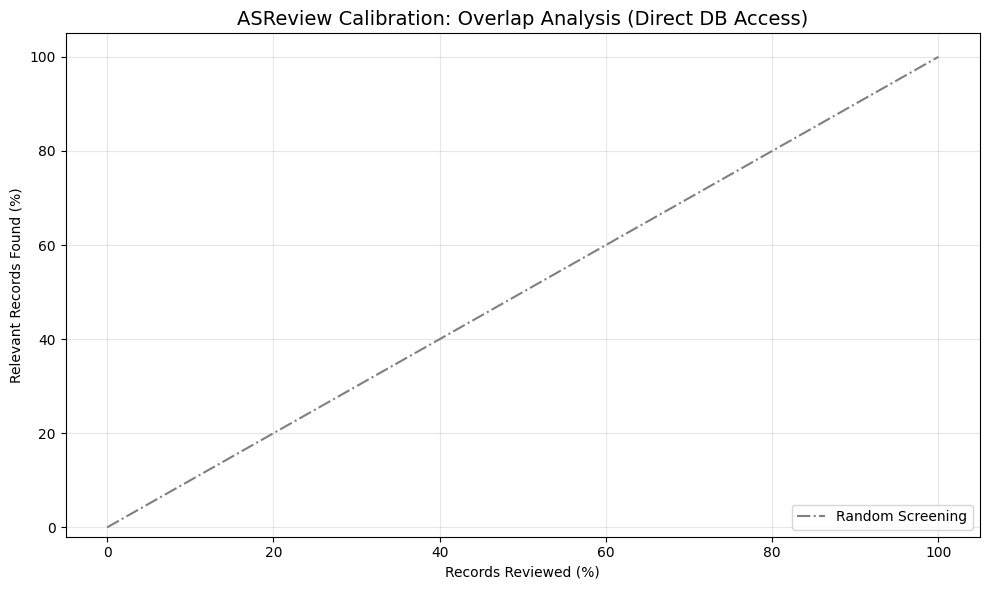

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3
import zipfile
import os
import shutil

# ================= 1. 终极数据提取函数 (不依赖 ASReview API) =================

def get_recall_data_nuclear(asreview_file_path):
    """
    将 .asreview 文件视为 zip 包，直接提取并读取其内部的 sqlite 数据库。
    """
    if not os.path.exists(asreview_file_path):
        print(f"⚠️ 文件未找到: {asreview_file_path}")
        return None, None
        
    # 创建一个临时文件夹来解压
    temp_extract_dir = "temp_extract_" + os.path.basename(asreview_file_path)
    db_path = None
    
    try:
        # 1. 解压文件
        with zipfile.ZipFile(asreview_file_path, 'r') as zip_ref:
            zip_ref.extractall(temp_extract_dir)
            
        # 2. 寻找数据库文件 (通常叫 results.sqlite 或 asreview.sqlite)
        for root, dirs, files in os.walk(temp_extract_dir):
            for file in files:
                if file.endswith(".sqlite"):
                    db_path = os.path.join(root, file)
                    break
        
        if not db_path:
            print(f"❌ 在 {asreview_file_path} 中找不到数据库文件。")
            return None, None
            
        # 3. 直接使用 sqlite3 连接
        conn = sqlite3.connect(db_path)
        
        # 尝试读取结果 (兼容不同版本的表名)
        try:
            # 绝大多数版本数据在 'results' 表中
            df_res = pd.read_sql_query("SELECT label FROM results ORDER BY rowid", conn)
        except:
            # 某些版本可能在 'record_table'
            df_res = pd.read_sql_query("SELECT label FROM record_table ORDER BY rowid", conn)
            
        conn.close()
        
        # 4. 计算召回率
        labels = df_res['label'].dropna().to_list()
        total_relevant = sum(labels)
        
        if total_relevant == 0:
            print(f"⚠️ 警告: {asreview_file_path} 中相关文献数为 0。")
            return [0, 100], [0, 0]

        x, y = [0], [0]
        found = 0
        for i, label in enumerate(labels):
            if label == 1:
                found += 1
            x.append((i + 1) / len(labels) * 100)
            y.append(found / total_relevant * 100)
            
        return x, y

    except Exception as e:
        print(f"❌ 终极提取失败 ({os.path.basename(asreview_file_path)}): {e}")
        return None, None
    finally:
        # 清理临时文件夹
        if os.path.exists(temp_extract_dir):
            shutil.rmtree(temp_extract_dir)

# ================= 2. 强制刷新并绘图 =================

plt.figure(figsize=(10, 6))

# 获取数据
x_nb, y_nb = get_recall_data_nuclear(os.path.join("simulation_results", "sim_nb.asreview"))
x_lr, y_lr = get_recall_data_nuclear(os.path.join("simulation_results", "sim_logistic.asreview"))

# 绘图逻辑
if x_nb:
    plt.plot(x_nb, y_nb, label="Naive Bayes (Baseline)", 
             color="#1f77b4", linewidth=5, alpha=0.5)
    print("✅ Naive Bayes 数据加载成功")

if x_lr:
    plt.plot(x_lr, y_lr, label="Logistic Regression (Challenger)", 
             color="#ff7f0e", linewidth=2, linestyle="--")
    print("✅ Logistic Regression 数据加载成功")

# 随机线
plt.plot([0, 100], [0, 100], color="gray", linestyle="-.", label="Random Screening")

plt.title("ASReview Calibration: Overlap Analysis (Direct DB Access)", fontsize=14)
plt.xlabel("Records Reviewed (%)")
plt.ylabel("Relevant Records Found (%)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.ylim(-2, 105)

plt.tight_layout()
plt.savefig("pilot_recall_curve_final.png", dpi=300)
print("\n🎉 终于成功了！图片已保存为 'pilot_recall_curve_final.png'。")
plt.show()